In [3]:
from scipy.special import roots_jacobi, eval_jacobi
import pandas as pd
import numpy as np
import uxarray as ux
import xarray as xr

In [4]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [197]:
grid_file = ux.open_grid('/home/hsingh/Downloads/TEMPEST_ne5.g')
node_connect = grid_file.face_node_connectivity

In [198]:
npts = 4
p_order = npts - 1
xinterior, w = roots_jacobi(p_order - 1,1,1) # returns interior GLL nodes from range -1 and 1
GLL_points = np.pad(xinterior, (1, 1), 'constant', constant_values=(-1, 1))

ref_coords = np.meshgrid(GLL_points, GLL_points[::-1])

### Define Derivative Operators:

In [7]:
# Assumes array_in has dims ('x2', 'y2'):
def pd_y(array_in, xr_D):
    return(xr.apply_ufunc(np.matmul,
           xr_D, array_in,
           input_core_dims=[['x2', 'y2'], ['x2', 'y2']],
           output_core_dims=[['x2', 'y2']],
           vectorize=True,
           dask="parallelized",
           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype]))

In [8]:
# Assumes array_in has dims ('n_face', 'x2', 'y2'):
def pd_x(array_in, xr_D):
    array_out = xr.apply_ufunc(np.matmul,
                   xr_D, array_in.transpose('n_face', 'y2', 'x2'),
                   input_core_dims=[['x2', 'y2'], ['y2', 'x2']],
                   output_core_dims=[['y2', 'x2']],
                   vectorize=True,
                   dask="parallelized",
                   output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Return a transposed array:
    return(array_out.transpose('n_face', 'x2', 'y2'))

In [199]:
def vandermonde(npts_values, return_type):
    # For the monomial basis: 
    if return_type == 'Monomial':
        return(np.vander(npts_values, increasing = True))
    elif return_type == 'Legendre':
        return(np.polynomial.legendre.legvander(npts_values, len(npts_values) - 1))

In [10]:
def Ld_vandermonde(npts_values): 
    
    LP = np.polynomial.legendre
    v_matrix = np.polynomial.legendre.legvander(npts_values, len(npts_values)-1)
    d_v_matrix = np.zeros_like(v_matrix)

    for i in range(len(npts_values)):
        # Coefficients for the i-th Legendre polynomial (e.g., [0, 0, 1] for P_2)
        coeffs = np.zeros(len(npts_values))
        coeffs[i] = 1

        # Compute the derivative of the i-th Legendre polynomial
        deriv_coeffs = LP.legder(coeffs, m=1) # m=1 for first derivative

        # Evaluate the derivative at the points x
        d_v_matrix[:, i] = LP.legval(npts_values, deriv_coeffs)
        
    return(d_v_matrix)

In [200]:
def return_D(V1, V2):
    return(np.matmul(V2, np.linalg.inv(V1)))

In [201]:
V1 = vandermonde(GLL_points, 'Legendre')
V2 = Ld_vandermonde(GLL_points)
D = return_D(V1, V2)

In [202]:
xr_D = xr.DataArray(data = D, coords = {'x2' : np.arange(npts),
                                        'y2' : np.arange(npts)}, dims = ['x2', 'y2'])

### Map GLL points to the sphere:

In [203]:
# Returns Cartesian coordinates on the unit sphere: 
# Fills in starting with C1 from the bottom left, moves counterclockwise:
# GLL_point 12 is c1, GLL_point 15 is c2, GLL_point 3 is c3, GLL_point 0 is c4

def map_cartesian(grid_file, ref_coords, GLL_points):
    
    # Define arrays for corners in x_2, y_2:
    node_connect = grid_file.face_node_connectivity
    
    # Return the x, y, z comps of element corners of faces:
    node_x = grid_file.node_x.isel(n_node = node_connect)
    node_y = grid_file.node_y.isel(n_node = node_connect)
    node_z = grid_file.node_z.isel(n_node = node_connect)
    
    t1 = (1 - ref_coords[0]) * (1 - ref_coords[1])
    t2 = (1 + ref_coords[0]) * (1 - ref_coords[1])
    t3 = (1 + ref_coords[0]) * (1 + ref_coords[1])
    t4 = (1 - ref_coords[0]) * (1 + ref_coords[1])
    
    r1 = ((1/4) * (np.outer(node_x.isel(n_max_face_nodes = 0), t1.reshape(-1))
                   + np.outer(node_x.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
                   + np.outer(node_x.isel(n_max_face_nodes = 2), t3.reshape(-1))
                   + np.outer(node_x.isel(n_max_face_nodes = 3), t4.reshape(-1)))).reshape(grid_file.n_face, len(GLL_points), len(GLL_points))
    
    r2 = ((1/4) * (np.outer(node_y.isel(n_max_face_nodes = 0), t1.reshape(-1))
                   + np.outer(node_y.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
                   + np.outer(node_y.isel(n_max_face_nodes = 2), t3.reshape(-1))
                   + np.outer(node_y.isel(n_max_face_nodes = 3), t4.reshape(-1)))).reshape(grid_file.n_face, len(GLL_points), len(GLL_points))
    
    r3 = ((1/4) * (np.outer(node_z.isel(n_max_face_nodes = 0), t1.reshape(-1))
                   + np.outer(node_z.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
                   + np.outer(node_z.isel(n_max_face_nodes = 2), t3.reshape(-1))
                   + np.outer(node_z.isel(n_max_face_nodes = 3), t4.reshape(-1)))).reshape(grid_file.n_face, len(GLL_points), len(GLL_points))
    
    r_vector = xr.Dataset(data_vars = {'x_comp' : (["n_face", "x2", "y2"], r1), 
                                       'y_comp' : (["n_face", "x2", "y2"], r2), 
                                       'z_comp' : (["n_face", "x2", "y2"], r3)},
                          coords = {'n_face' : (('n_face'), node_x.coords['n_face'].values),
                                    'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))})
    
    r_norm = r_vector / np.sqrt((r_vector['x_comp'] ** 2) + (r_vector['y_comp'] ** 2) + (r_vector['z_comp'] ** 2))
    return(r_norm, np.sqrt((r_vector['x_comp'] ** 2) + (r_vector['y_comp'] ** 2) + (r_vector['z_comp'] ** 2)))

In [204]:
# Convert Cartesian coordinates on the unit sphere to lat/lon in radians: 

def map_spherical(input_array):
    
    # Note: lon returned from [-pi, pi], lat returned from [0, pi]
    lon_array = np.arctan2(input_array['y_comp'], input_array['x_comp'])
    lat_array = np.arccos(input_array['z_comp'])
    
    # Shift lon to [0, 2pi] and lat to [pi/2, -pi/2]:
    lat_shift = -(lat_array - (np.pi / 2))
    lon_shift = np.where(lon_array < 0, lon_array + (2 * np.pi), lon_array)
    
    return(xr.Dataset(data_vars = {'lat' : (["n_face", "x2", "y2"], lat_shift.data), 
                                   'lon' : (["n_face", "x2", "y2"], lon_shift.data)},
                      coords = {'n_face' : (('n_face'), input_array.coords['n_face'].values), 
                                'GLL_points' : (('x2', 'y2'), input_array.coords['GLL_points'].values)}))

### Determine neighbors for DSS:

In [205]:
# Insert 2 additional data_vars, one for shared edges and one for shared corners:

def return_neighbors_DG(grid_array, value_array, npts):
    # Preallocate arrays for corners and edges:
    edge_mapping = {(0, 1) : 'edge_1', (1, 2) : 'edge_2',
                    (2, 3) : 'edge_3', (0, 3) : 'edge_4'}
    GLL_index = np.array(([npts-1, 0], [npts-1, npts-1], [0, npts-1], [0, 0]))
    reverse_list = [('edge_2', 'edge_2'), ('edge_2', 'edge_3'), ('edge_1', 'edge_4'), 
                    ('edge_1', 'edge_1'), ('edge_3', 'edge_3'), ('edge_4', 'edge_4')]
    
    # -1 is mask value for empty arrays:
    edge_neighbors = xr.DataArray(data = np.full((grid_array.n_face, 3, npts, npts + 2), -1), 
                                  coords = {'n_face' : np.arange(grid_array.n_face),
                                            'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) * (len(GLL_points) + 2)).reshape(len(GLL_points), len(GLL_points) + 2))},
                                  dims = ['n_face', 'n_edges', 'x2', 'y2']) 
    
    for value in np.arange(grid_array.n_node):
        index_array = np.where(grid_array.face_node_connectivity == value)[0]
        node_array = grid_array.face_node_connectivity[index_array]
        
        # Create matrix tracking which elements overlap across rows of node_array: 
        shared_counts = np.triu(np.sum(np.sum(np.array([node_array.values[i, :] == node_array.values[:, :, None] for i in np.arange(node_array.shape[0])]),
                                axis = -1), axis = -1))

        a, b = np.where(shared_counts == 2)
        shared_edges = list(zip(a, b))
            
        for pair in shared_edges:
            edge_nodes, i_a, j_b = np.intersect1d(node_array[pair[0]], node_array[pair[1]], return_indices=True) 
            
            # Index edge for one face:
            i_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][0], GLL_index[j_b[1]][0]])))
            j_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][1], GLL_index[j_b[1]][1]])))
            
            # Index edge for adjacent face:
            i_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][0], GLL_index[i_a[1]][0]])))
            j_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][1], GLL_index[i_a[1]][1]])))
            
            # Modify indices to account for DG corners: 
            if len(j_idx_2) == 2:
                j_idx_2 = np.array([1, npts])
            elif (len(j_idx_2) == 1) and (j_idx_2[0] == npts-1):
                j_idx_2 = np.array([npts+1])
            if len(j_idx_1) == 2:
                j_idx_1 = np.array([1, npts])
            elif (len(j_idx_1) == 1) and (j_idx_1[0] == npts-1):
                j_idx_1 = np.array([npts+1])
            
            # Generate point-by-point indices: 
            GLL_idx_2 = tuple(zip(np.linspace(i_idx_2[0], i_idx_2[-1], npts, dtype = int), 
                                  np.linspace(j_idx_2[0], j_idx_2[-1], npts, dtype = int)))
            GLL_idx_1 = tuple(zip(np.linspace(i_idx_1[0], i_idx_1[-1], npts, dtype = int), 
                                  np.linspace(j_idx_1[0], j_idx_1[-1], npts, dtype = int)))
            
            # Move flag here:
            if (tuple(reversed((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))))) in reverse_list) or ((edge_mapping.get(tuple(sorted(j_b))), edge_mapping.get(tuple(sorted(i_a)))) in reverse_list):
                GLL_idx_2 = GLL_idx_2[::-1]
                GLL_idx_1 = GLL_idx_1[::-1]
                
            # Top/bottom edges:
            if len(i_idx_2) == 1:
                edge_neighbors.isel(n_face = index_array[pair[1]])[0][i_idx_2[0] : i_idx_2[-1] + 1, j_idx_2[0] : j_idx_2[-1] + 1].values[:] = np.full((len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1))), index_array[pair[0]])
                edge_neighbors.isel(n_face = index_array[pair[1]])[1:3].isel(x2 = slice(i_idx_2[0], i_idx_2[-1] + 1),
                                                                                          y2 = slice(j_idx_2[0], j_idx_2[-1] + 1)).values[:] = np.array(GLL_idx_1).transpose().reshape(2, len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1)))            
            if len(i_idx_1) == 1:
                edge_neighbors.isel(n_face = index_array[pair[0]])[0][i_idx_1[0] : i_idx_1[-1] + 1, j_idx_1[0] : j_idx_1[-1] + 1].values[:] = np.full((len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1))), index_array[pair[1]])
                edge_neighbors.isel(n_face = index_array[pair[0]])[1:3].isel(x2 = slice(i_idx_1[0], i_idx_1[-1] + 1), 
                                                                                          y2 = slice(j_idx_1[0], j_idx_1[-1] + 1)).values[:] = np.array(GLL_idx_2).transpose().reshape(2, len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1)))
            # Left/right edges: 
            if len(j_idx_2) == 1:
                edge_neighbors.isel(n_face = index_array[pair[1]])[0][i_idx_2[0] : i_idx_2[-1] + 1, j_idx_2[0] : j_idx_2[-1] + 1].values[:] = np.full((len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1))), index_array[pair[0]])
                edge_neighbors.isel(n_face = index_array[pair[1]])[1:3].isel(x2 = slice(i_idx_2[0], i_idx_2[-1] + 1), 
                                                                                          y2 = slice(j_idx_2[0], j_idx_2[-1] + 1)).values[:] = np.array(GLL_idx_1).transpose().reshape(2, len(np.arange(i_idx_2[0], i_idx_2[-1] + 1)), len(np.arange(j_idx_2[0], j_idx_2[-1] + 1)))
            if len(j_idx_1) == 1:
                edge_neighbors.isel(n_face = index_array[pair[0]])[0][i_idx_1[0] : i_idx_1[-1] + 1, j_idx_1[0] : j_idx_1[-1] + 1].values[:] = np.full((len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1))), index_array[pair[1]])
                edge_neighbors.isel(n_face = index_array[pair[0]])[1:3].isel(x2 = slice(i_idx_1[0], i_idx_1[-1] + 1), 
                                                                                          y2 = slice(j_idx_1[0], j_idx_1[-1] + 1)).values[:] = np.array(GLL_idx_2).transpose().reshape(2, len(np.arange(i_idx_1[0], i_idx_1[-1] + 1)), len(np.arange(j_idx_1[0], j_idx_1[-1] + 1)))            
    return(edge_neighbors)

In [879]:
index_array = np.where(grid_file.face_node_connectivity == 20)[0]
node_array = grid_file.face_node_connectivity[index_array]

GLL_index = np.array(([npts-1, 0], [npts-1, npts-1], [0, npts-1], [0, 0]))
shared_counts = np.triu(np.sum(np.sum(np.array([node_array.values[i, :] == node_array.values[:, :, None] for i in np.arange(node_array.shape[0])]),
                                axis = -1), axis = -1))
a, b = np.where(shared_counts == 2)
shared_edges = list(zip(a, b))

pair = shared_edges[3]
edge_nodes, i_a, j_b = np.intersect1d(node_array[pair[0]], node_array[pair[1]], return_indices=True)

# Index edge for one face:
i_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][0], GLL_index[j_b[1]][0]])))
j_idx_2 = np.sort(np.unique(np.array([GLL_index[j_b[0]][1], GLL_index[j_b[1]][1]])))
            
# Index edge for adjacent face:
i_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][0], GLL_index[i_a[1]][0]])))
j_idx_1 = np.sort(np.unique(np.array([GLL_index[i_a[0]][1], GLL_index[i_a[1]][1]])))

# Modify indices to account for DG corners: 
if len(j_idx_2) == 2:
    i_idx_2 = np.array([1, npts])
if len(j_idx_1) == 2:
    i_idx_1 = np.array([1, npts])
if j_idx_1 == npts-1:
    j_idx_1 = np.array([npts+1])
if j_idx_2 == npts-1:
    j_idx_2 = np.array([npts+1])

GLL_idx_2 = tuple(zip(np.linspace(i_idx_2[0], i_idx_2[-1], npts, dtype = int), 
                      np.linspace(j_idx_2[0], j_idx_2[-1], npts, dtype = int)))
GLL_idx_1 = tuple(zip(np.linspace(i_idx_1[0], i_idx_1[-1], npts, dtype = int), 
                      np.linspace(j_idx_1[0], j_idx_1[-1], npts, dtype = int)))

In [221]:
neigh_test = return_neighbors_DG(grid_file, map_cartesian(grid_file, ref_coords, GLL_points)[0], npts)

In [1064]:
lft_concat = xr.concat([lr_array_flux_n[:, :, 0], tb_array_flux_n], dim = 'y2')
right_concat = xr.concat([lft_concat, lr_array_flux_n[:, :, -1]], dim = 'y2')
edge_flux_array = right_concat.assign_coords({'y2' : np.arange(npts + 2)})

In [1065]:
# For edges:
mask_array = (neigh_test.isel(n_edges = 0) >= 0).rename({"n_face": "face_val"})

nf_idx = neigh_test.isel(n_edges = 0).rename({"n_face": "face_val"})
x2_idx = neigh_test.isel(n_edges = 1).rename({"n_face": "face_val"})
y2_idx = neigh_test.isel(n_edges = 2).rename({"n_face": "face_val"})

In [1066]:
neigh_edge_flux = edge_flux_array.drop_vars(['x2', 'y2']).isel(n_face = nf_idx, x2 = x2_idx, y2 = y2_idx).where(mask_array).fillna(0)

In [1067]:
edge_flux_array[1276]

<xarray.DataArray (x2: 4, y2: 6)>
array([[-5.07586673e-06,  1.38342521e-06,  7.08169217e-06,
         7.25810555e-06,  1.46102387e-06,  6.61731463e-06],
       [-2.04354143e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  2.63053913e-05],
       [-1.42939098e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  1.80031972e-05],
       [-2.28378581e-06, -4.54974779e-07, -2.29599714e-06,
        -2.30253753e-06, -4.57703686e-07,  2.83610566e-06]])
Coordinates:
  * x2          (x2) int64 0 1 2 3
  * y2          (y2) int64 0 1 2 3 4 5
    n_face      int64 1276
    GLL_points  (x2, y2) int64 0 0 1 2 3 3 4 4 5 ... 10 11 11 12 12 13 14 15 15

In [1068]:
neigh_edge_flux[1276]

<xarray.DataArray (x2: 4, y2: 6)>
array([[ 5.07586673e-06, -1.38342521e-06, -7.08169217e-06,
        -7.25810555e-06, -1.46102387e-06, -6.61731463e-06],
       [ 2.04354143e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -2.63053913e-05],
       [ 1.42939098e-05,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -1.80031972e-05],
       [ 2.28378581e-06,  4.54974779e-07,  2.29599714e-06,
         2.30253753e-06,  4.57703686e-07, -2.83610566e-06]])
Coordinates:
    n_face    (x2, y2) int64 1275 1291 1291 1291 1291 ... 1261 1261 1261 1277
    face_val  int64 1276
Dimensions without coordinates: x2, y2

In [936]:
np.where(np.round(edge_flux_array, 13) != np.round(-neigh_edge_flux.drop_vars(['n_face']).rename({'face_val' : 'n_face'}), 13))[0]

array([1261, 1276, 1324, 1325])

### Define the derivative of the map from the reference element to the sphere's surface:

In [206]:
# Note: Returns the transpose of the d_rmap 2x2 matrix for each GLL_node:

def d_rmap(grid_file, ref_coords, GLL_points):
    
    node_connect = grid_file.face_node_connectivity
    node_x = grid_file.node_x.isel(n_node = node_connect)
    node_y = grid_file.node_y.isel(n_node = node_connect)
    node_z = grid_file.node_z.isel(n_node = node_connect)
    
    ones_array = xr.DataArray(np.ones((grid_file.n_face, npts * npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : ('xy', np.arange(npts * npts))},
                           dims = ['n_face', 'xy'])

    zeros_array = xr.DataArray(np.zeros((grid_file.n_face, npts * npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : ('xy', np.arange(npts * npts))},
                           dims = ['n_face', 'xy'])
    # x2 values: 
    t1 = -(1 - ref_coords[1])
    t2 = (1 - ref_coords[1])
    t3 = (1 + ref_coords[1])
    t4 = -(1 + ref_coords[1])

    # x1 values:
    t5 = -(1 - ref_coords[0])
    t6 = -(1 + ref_coords[0])
    t7 = (1 + ref_coords[0])
    t8 = (1 - ref_coords[0])
    
    # Each array below is shape (n_face, npts * npts):
    c1_x = ((np.outer(node_x.isel(n_max_face_nodes = 0), t1.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
           + np.outer(node_x.isel(n_max_face_nodes = 2), t3.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
    c1_y = ((np.outer(node_y.isel(n_max_face_nodes = 0), t1.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
           + np.outer(node_y.isel(n_max_face_nodes = 2), t3.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
    c1_z = ((np.outer(node_z.isel(n_max_face_nodes = 0), t1.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 1), t2.reshape(-1)) 
           + np.outer(node_z.isel(n_max_face_nodes = 2), t3.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 3), t4.reshape(-1))))
    
    c2_x = ((np.outer(node_x.isel(n_max_face_nodes = 0), t5.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
           + np.outer(node_x.isel(n_max_face_nodes = 2), t7.reshape(-1))
           + np.outer(node_x.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
    c2_y = ((np.outer(node_y.isel(n_max_face_nodes = 0), t5.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
           + np.outer(node_y.isel(n_max_face_nodes = 2), t7.reshape(-1))
           + np.outer(node_y.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
    c2_z = ((np.outer(node_z.isel(n_max_face_nodes = 0), t5.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 1), t6.reshape(-1)) 
           + np.outer(node_z.isel(n_max_face_nodes = 2), t7.reshape(-1))
           + np.outer(node_z.isel(n_max_face_nodes = 3), t8.reshape(-1))))
    
    # Each array below is shape (3, n_face, npts * npts):
    coord_vals = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0]).stack(xy = ("x2", "y2"))
    
    r1_t1 = ((np.sin(coord_vals['lon']) ** 2) * (np.cos(coord_vals['lat']) ** 2)) + (np.sin(coord_vals['lat']) ** 2)
    r1_t2 = (-0.5) * (np.sin(2 * coord_vals['lon'])) * (np.cos(coord_vals['lat']) ** 2)
    r1_t3 = -(np.cos(coord_vals['lon'])) * (np.sin(coord_vals['lat']))

    r1 = xr.concat([r1_t1, r1_t2, r1_t3], dim = 'r_dim')
    
    r2_t1 = (-0.5) * (np.sin(2 * coord_vals['lon'])) * (np.cos(coord_vals['lat']) ** 2)
    r2_t2 = ((np.cos(coord_vals['lon']) ** 2) * (np.cos(coord_vals['lat']) ** 2)) + (np.sin(coord_vals['lat']) ** 2)
    r2_t3 = -(np.sin(coord_vals['lon'])) * (np.sin(coord_vals['lat']))

    r2 = xr.concat([r2_t1, r2_t2, r2_t3], dim = 'r_dim')
    
    r3_t1 = (-0.5) * (np.cos(coord_vals['lon'])) * (np.sin(2 * coord_vals['lat']))
    r3_t2 = (-0.5) * (np.sin(coord_vals['lon'])) * (np.sin(2 * coord_vals['lat']))
    r3_t3 = np.cos(coord_vals['lat'])

    r3 = xr.concat([r3_t1, r3_t2, r3_t3], dim = 'r_dim')
    
    # Each array below is (3, n_face, npts * npts):
    sph_1 = (r1 * c1_x) + (r2 * c1_y) + (r3 * c1_z)
    sph_2 = (r1 * c2_x) + (r2 * c2_y) + (r3 * c2_z)
    
    # Each array below is (2, n_face, npts * npts):
    sing_r1 = xr.concat([-(0.25) * np.sin(coord_vals['lon']), zeros_array], dim = 'r_dim')
    sing_r2 = xr.concat([(0.25) * np.cos(coord_vals['lon']), zeros_array], dim = 'r_dim')
    sing_r3 = xr.concat([zeros_array, (0.25) * ones_array], dim = 'r_dim')
    
    # Return the rows of the D matrix for each GLL node: 
    D_r1 = (sing_r1 * sph_1.isel(r_dim = 0)) + (sing_r2 * sph_1.isel(r_dim = 1)) + (sing_r3 * sph_1.isel(r_dim = 2))
    D_r2 = (sing_r1 * sph_2.isel(r_dim = 0)) + (sing_r2 * sph_2.isel(r_dim = 1)) + (sing_r3 * sph_2.isel(r_dim = 2))
    
    return(xr.concat([D_r1.unstack('xy'), 
                      D_r2.unstack('xy')], dim = 'c_dim') / map_cartesian(grid_file, ref_coords, GLL_points)[1])

### Write the global nodal weights matrix:

In [207]:
def quad_weights(npts_values):
    
    # Values in f_array result from exact integration:
    f_array = np.zeros(len(npts_values))
    f_array[0] = 2
    
    # Define basis matrix for Legendre polynomials: 
    V = np.polynomial.legendre.legvander(npts_values, len(npts_values) - 1).transpose()
    return(np.matmul(np.linalg.inv(V), f_array))

In [234]:
det_J = xr.apply_ufunc(np.linalg.det,
                           d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                           input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                           vectorize=True, dask="parallelized", 
                           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
weights_2D_array = xr.DataArray(np.outer(quad_weights(GLL_points), quad_weights(GLL_points)),
                                    coords = {'x2': np.arange(npts), 'y2' : np.arange(npts)}, dims = ['x2', 'y2'])

W_ij = (det_J) * weights_2D_array

### Strong divergence operator:

In [236]:
def stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D):
    
    # Compute the inverse of d_rmap:
    d_inv = xr.apply_ufunc(np.linalg.inv,
            d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
            input_core_dims=[["r_dim","c_dim"]],
            output_core_dims=[["r_dim","c_dim"]],
            vectorize=True, dask="parallelized", 
            output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Convert physical vectors to contravariant vectors:
    contra_vector = xr.apply_ufunc(np.matmul,
                    d_inv, v_vector.transpose('n_face', 'x2', 'y2', 'r_dim'),
                    input_core_dims=[["r_dim", "c_dim"], ["r_dim"]],
                    output_core_dims=[["r_dim"]],
                    vectorize=True, dask="parallelized",
                    output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Implement divergence formula from Heinbockel, pg. 175; Apply D to contra_x, contra_y:    
    det_J = xr.apply_ufunc(np.linalg.det,
                           d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
                           input_core_dims=[["r_dim","c_dim"]], output_core_dims=[[]],
                           vectorize=True, dask="parallelized", 
                           output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    dy_contra = -pd_y(det_J * contra_vector.isel(r_dim = 1), xr_D)
    dx_contra = pd_x(det_J * contra_vector.isel(r_dim = 0), xr_D)
    return((1 / det_J) * (dy_contra + dx_contra))    

### Strong gradient operator:

In [210]:
def stg_grad(array_in, xr_D):
    G_dx = pd_x(array_in, xr_D)
    G_dy = -pd_y(array_in, xr_D)
    da_G = xr.concat([G_dx, G_dy], dim = 'c_dim')
    
    d_inv_tran = xr.apply_ufunc(np.linalg.inv,
                    d_rmap(grid_file, ref_coords, GLL_points),
                    input_core_dims=[["c_dim","r_dim"]],
                    output_core_dims=[["c_dim","r_dim"]],
                    vectorize=True, dask="parallelized", 
                    output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    # Map the gradient vector from covariant to the physical domain:
    phys_vector = xr.apply_ufunc(np.matmul, d_inv_tran, da_G,
                                 input_core_dims=[["c_dim", "r_dim"], ["c_dim"]],
                                 output_core_dims=[["c_dim"]],
                                 vectorize=True, dask="parallelized",
                                 output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    
    return(phys_vector)

### Weak divergence operator:

In [211]:
def weak_div(u_comp, v_comp, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij):
    return_array = np.zeros([grid_file.n_face, npts, npts])
    test_func_array = xr.DataArray(np.eye(npts * npts, dtype=int).reshape(npts * npts, npts, npts), 
                               coords = {'test_func' : np.arange(npts * npts),
                                         'x2' : np.arange(len(GLL_points)), 'y2' : np.arange(len(GLL_points))}, dims = ['test_func', 'x2', 'y2'])
    test_func_array = test_func_array.expand_dims(n_face = grid_file.n_face).assign_coords(n_face = np.arange(grid_file.n_face))
    
    for i in np.arange(npts * npts):
        grad_test = stg_grad(test_func_array.isel(test_func = i), xr_D)
        dot_array = (u_comp * grad_test.isel(c_dim = 0)) + (v_comp * grad_test.isel(c_dim = 1))
        quad_int_array = np.sum((dot_array * W_ij).transpose('n_face', 'x2', 'y2'), axis = (1, 2))
        row_i, col_i = np.where(test_func_array.isel(test_func = i)[0] == 1)
        
        return_array[:, row_i[-1], col_i[-1]] = -quad_int_array
        
    return(xr.DataArray(return_array, coords = {'n_face' : np.arange(grid_file.n_face), 'x2' : np.arange(len(GLL_points)),
                                                'y2' : np.arange(len(GLL_points))}, dims = ['n_face', 'x2', 'y2']))

### DG Boundary Term:

In [212]:
# From Lauritzen 2012:

def init_gaussian(lat_array, lon_array):
    # Center at (x, y, z) = (1, 0, 0)
    t1 = ((np.cos(lat_array) * np.cos(lon_array)) + 1) ** 2
    t2 = (np.cos(lat_array) * np.sin(lon_array)) ** 2
    t3 = (np.sin(lat_array)) ** 2
    
    return((0.95 * np.exp(-5 * (t1 + t2 + t3))).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}))

In [213]:
# From https://docs.e3sm.org/CMDV-testing/SWTC1.html:

def init_cosine_bell(lat_array, lon_array, h_0):
    # Compute great circle distance first; note a is equal to 1
    # Center at [pi, 0]
    r = np.arccos(np.cos(lat_array) * np.cos(lon_array - np.pi))
    r_mask = (r < (1 / 3))
    
    # Compute cosine bell height field:
    height_field = (h_0 / 2) * (1 + np.cos((np.pi * r) / (1 / 3)))
    return(height_field.where(r_mask).fillna(0).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}))

In [223]:
u_comp = np.cos(map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat'])
v_comp = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                      coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))},
                      dims = ['n_face', 'x2', 'y2'])

In [224]:
lat_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat']
lon_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lon']

gauss_field = init_gaussian(lat_array, lon_array)

In [218]:
# Returns a two-component vector:
def transport_analytic_flux(u, v, scalar_field):
    return(xr.concat([u * scalar_field, v * scalar_field], dim = 'r_dim'))

In [225]:
# Run this portion once for the DG boundary term:

neigh_test = return_neighbors_DG(grid_file, map_cartesian(grid_file, ref_coords, GLL_points)[0], npts)
mask_array = (neigh_test.isel(n_edges = 0) >= 0).rename({"n_face": "face_val"})

nf_idx = neigh_test.isel(n_edges = 0).rename({"n_face": "face_val"})
x2_idx = neigh_test.isel(n_edges = 1).rename({"n_face": "face_val"})
y2_idx = neigh_test.isel(n_edges = 2).rename({"n_face": "face_val"})

In [67]:
# Note: The DG term below is written so that normal vectors from adjacent elements at shared edges point inwards ...
# this changes the sign infront of the boundary term in the DG transport equation. 

In [237]:
d_inv = xr.apply_ufunc(np.linalg.inv,
            d_rmap(grid_file, ref_coords, GLL_points).transpose("r_dim", "c_dim", 'n_face', 'x2', 'y2'),
            input_core_dims=[["r_dim","c_dim"]],
            output_core_dims=[["r_dim","c_dim"]],
            vectorize=True, dask="parallelized", 
            output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])

In [238]:
def return_normal(comp_in, det_J, d_inv):
    contra_vector = xr.apply_ufunc(np.matmul,
                    d_inv, comp_in.transpose('n_face', 'x2', 'y2', 'r_dim'),
                    input_core_dims=[["r_dim", "c_dim"], ["r_dim"]], output_core_dims=[["r_dim"]],
                    vectorize=True, dask="parallelized", output_dtypes=[d_rmap(grid_file, ref_coords, GLL_points).dtype])
    return(det_J * contra_vector)

####  Centered Boundary Flux:

In [32]:
def DG_centered_flux(u_comp, v_comp, scalar_field, det_J, d_inv, npts, nf_idx, x2_idx, y2_idx):
    lr_array = np.zeros((npts, npts))
    tb_array = np.zeros((npts, npts))
    lr_array[:, 0] = lr_array[:, -1] = 1
    tb_array[0, :] = tb_array[-1, :] = 1
    b_array = np.ones((npts, npts))
    b_array[-1, :] = -1
        
    # Compute fluxes at element edges: 
    line_int_weights = np.ones((npts, npts))
    line_int_weights[0, :] = line_int_weights[-1, :] = quad_weights(GLL_points)
    
    flux_array = transport_analytic_flux(u_comp, v_comp, scalar_field)
    tb_array_flux_n = return_normal((flux_array * tb_array), det_J, d_inv).isel(r_dim = 1) * line_int_weights * b_array
    lr_array_flux_n = return_normal((flux_array * lr_array), det_J, d_inv).isel(r_dim = 0) * np.rot90(line_int_weights, k = 1) * np.rot90(b_array, k = -1)

    # Expand dimensions of grid arrays for duplic. values at corners:
    lft_concat = xr.concat([lr_array_flux_n[:, :, 0], tb_array_flux_n], dim = 'y2')
    right_concat = xr.concat([lft_concat, lr_array_flux_n[:, :, -1]], dim = 'y2')
    edge_flux_array = right_concat.assign_coords({'y2' : np.arange(npts + 2)})
    
    # Return neighbor nodal values:
    neigh_edge_flux = edge_flux_array.drop_vars(['x2', 'y2']).isel(n_face = nf_idx, x2 = x2_idx, y2 = y2_idx).where(mask_array).fillna(0)

    # Compute centered flux - both normals point into the element:
    cnfx_array = (0.5 * (neigh_edge_flux.drop_vars('n_face').rename({'face_val' : 'n_face'}) - edge_flux_array))
    
    # Return two arrays - each has different corner flux values:
    cnfx_tb_array = cnfx_array.isel(y2 = slice(1, npts+1)).assign_coords({'y2' : np.arange(npts)})
    cnfx_lr_array = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                               coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 
                                         'x2' : (('x2'), np.arange(len(GLL_points))), 'y2' : (('y2'), np.arange(len(GLL_points)))},
                               dims = ['n_face', 'x2', 'y2'])
    cnfx_lr_array.isel(y2 = 0).values[:] = cnfx_array.isel(y2 = 0)
    cnfx_lr_array.isel(y2 = -1).values[:] = cnfx_array.isel(y2 = -1).assign_coords({'y2' : npts-1})
    return(cnfx_tb_array + cnfx_lr_array)

In [1163]:
DG_centered_flux(u_comp, v_comp, gauss_field, det_J, d_inv, npts,
                 nf_idx, x2_idx, y2_idx)[1]

<xarray.DataArray (x2: 4, y2: 4)>
array([[ 1.462615851982824e-10,  0.000000000000000e+00,
         0.000000000000000e+00, -1.731070345558719e-10],
       [ 8.526561933199277e-10,  0.000000000000000e+00,
         0.000000000000000e+00, -9.997868112015617e-10],
       [ 1.100568182993489e-09,  0.000000000000000e+00,
         0.000000000000000e+00, -1.270804204023631e-09],
       [ 2.586120551612043e-10,  0.000000000000000e+00,
         0.000000000000000e+00, -2.957590542036829e-10]])
Coordinates:
    n_face   int64 10
  * x2       (x2) int64 0 1 2 3
  * y2       (y2) int64 0 1 2 3

#### Upwinded Boundary Flux:

In [33]:
# For a non-divergent wind field, I will assume that element boundaries and their neighboring boundaries 
# have equal and opposite velocity normal values:

In [286]:
# 1. Compute the outward velocity normal at element edges 
# 2. Compute the numerical flux normal at element edges and return the values of the neighbors
# 3. If outward velocity normal is +/-, choose the local/neighbor element edge -> confirm this 

def DG_upwind_flux(u_comp, v_comp, scalar_field, det_J, d_inv, npts, nf_idx, x2_idx, y2_idx):
    lr_array = np.zeros((npts, npts))
    tb_array = np.zeros((npts, npts))
    lr_array[:, 0] = lr_array[:, -1] = 1
    tb_array[0, :] = tb_array[-1, :] = 1
    b_array = np.ones((npts, npts))
    b_array[-1, :] = -1
        
    # Compute fluxes at element edges: 
    line_int_weights = np.ones((npts, npts))
    line_int_weights[0, :] = line_int_weights[-1, :] = quad_weights(GLL_points)
    
    flux_array = transport_analytic_flux(u_comp, v_comp, scalar_field)
    tb_array_flux_n = return_normal((flux_array * tb_array), det_J, d_inv).isel(r_dim = 1) * line_int_weights * b_array
    lr_array_flux_n = return_normal((flux_array * lr_array), det_J, d_inv).isel(r_dim = 0) * np.rot90(line_int_weights, k = 1) * np.rot90(b_array, k = -1)

    # Expand dimensions of grid arrays for duplic. values at corners:
    lft_flx_concat = xr.concat([lr_array_flux_n[:, :, 0], tb_array_flux_n], dim = 'y2')
    rgt_flx_concat = xr.concat([lft_flx_concat, lr_array_flux_n[:, :, -1]], dim = 'y2')
    edge_flux_array = rgt_flx_concat.assign_coords({'y2' : np.arange(npts + 2)})
    
    # Return neighbor nodal values:
    neigh_edge_flux = edge_flux_array.drop_vars(['x2', 'y2']).isel(n_face = nf_idx, x2 = x2_idx, y2 = y2_idx).where(mask_array).fillna(0)
    
    # Compute the velocity normal(s):
    vlc_vector = xr.concat([u_comp, v_comp], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), y2 = np.arange(len(GLL_points)))
    vlc_tb_normal = return_normal((vlc_vector * tb_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}), det_J, d_inv).isel(r_dim = 1) * b_array
    vlc_lr_normal = return_normal((vlc_vector * lr_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}), det_J, d_inv).isel(r_dim = 0) * np.rot90(b_array, k = -1)
    
    # Expand dimensions of grid arrays for duplic. values at corners:
    lft_vlc_concat = xr.concat([vlc_lr_normal[:, :, 0], vlc_tb_normal], dim = 'y2')
    rgt_vlc_concat = xr.concat([lft_vlc_concat, vlc_lr_normal[:, :, -1]], dim = 'y2')
    edge_vlc_array = rgt_vlc_concat.assign_coords({'y2' : np.arange(npts + 2)})
    
    vlc_mask_array = (edge_vlc_array > 0)
    # The first array keeps edge flux values where the velocity normal is positive:
    # The second array keeps neighboring edge flux values w/ opposite sign where the velocity normal is negative:
    upwind_flux = edge_flux_array.where(vlc_mask_array).fillna(0) - neigh_edge_flux.drop_vars('n_face').rename({'face_val' : 'n_face'}).where(~vlc_mask_array).fillna(0)
    
    # Return two arrays - each has different corner flux values:
    upwd_tb_array = upwind_flux.isel(y2 = slice(1, npts+1)).assign_coords({'y2' : np.arange(npts)})
    upwd_lr_array = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                                 coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 
                                           'x2' : (('x2'), np.arange(len(GLL_points))), 'y2' : (('y2'), np.arange(len(GLL_points)))},
                                 dims = ['n_face', 'x2', 'y2'])
    upwd_lr_array.isel(y2 = 0).values[:] = upwind_flux.isel(y2 = 0)
    upwd_lr_array.isel(y2 = -1).values[:] = upwind_flux.isel(y2 = -1).assign_coords({'y2' : npts-1})
    return(upwd_tb_array + upwd_lr_array)

In [1341]:
DG_upwind_flux(u_comp, v_comp, gauss_field, det_J, d_inv, npts, nf_idx, x2_idx, y2_idx)

<xarray.DataArray (n_face: 1350, x2: 4, y2: 6)>
array([[[6.429343316922984e-10, 2.965647133014392e-10,
         1.260708075268279e-09, 9.714094960692093e-10,
         1.656055784429610e-10, 4.181492808899901e-10],
        [3.485997480403184e-09, 0.000000000000000e+00,
         0.000000000000000e+00, 0.000000000000000e+00,
         0.000000000000000e+00, 2.310208571064889e-09],
        [3.990438785584664e-09, 0.000000000000000e+00,
         0.000000000000000e+00, 0.000000000000000e+00,
         0.000000000000000e+00, 2.728511972966295e-09],
        [8.694793658826801e-10, 4.347396829413406e-10,
         1.885633677695338e-09, 1.499104152922443e-09,
         2.603189780986631e-10, 6.063802908251407e-10]],

       [[4.181492808899901e-10, 1.578678534473567e-10,
         6.818028582156392e-10, 5.384245812998069e-10,
         9.311610873986309e-11, 2.917063913114484e-10],
        [2.310208571064889e-09, 0.000000000000000e+00,
         0.000000000000000e+00, 0.000000000000000e+00,
         0.000000000000000e+00, 1.639577777512782e-09],
        [2.728511972966295e-09, 0.000000000000000e+00,
...
         0.000000000000000e+00, 3.041277437838417e-04],
        [3.092962449128490e-04, 0.000000000000000e+00,
         0.000000000000000e+00, 0.000000000000000e+00,
         0.000000000000000e+00, 1.986617848181440e-04],
        [4.716144284772658e-05, 3.263959296295547e-05,
         1.593299282306125e-04, 1.506524912620062e-04,
         2.881439383811425e-05, 3.022670071735307e-05]],

       [[7.828352039606293e-05, 5.564496996985635e-05,
         2.651150200945211e-04, 2.409937189927530e-04,
         4.498109308283806e-05, 4.498109308283809e-05],
        [3.041277437838417e-04, 0.000000000000000e+00,
         0.000000000000000e+00, 0.000000000000000e+00,
         0.000000000000000e+00, 1.744895114623225e-04],
        [1.986617848181440e-04, 0.000000000000000e+00,
         0.000000000000000e+00, 0.000000000000000e+00,
         0.000000000000000e+00, 1.138388970959166e-04],
        [3.022670071735307e-05, 3.022670071735306e-05,
         1.438362618926584e-04, 1.305832246481156e-04,
         2.436421352280158e-05, 1.731840779459438e-05]]])
Coordinates:
  * x2          (x2) int64 0 1 2 3
  * y2          (y2) int64 0 1 2 3 4 5
  * n_face      (n_face) int64 0 1 2 3 4 5 6 ... 1344 1345 1346 1347 1348 1349
    GLL_points  (x2, y2) int64 0 0 1 2 3 3 4 4 5 ... 10 11 11 12 12 13 14 15 15

In [1215]:
# Check for non-divergent wind field, velocity normal values at element boundaries and neighboring boundaries 
# are equal and opposite:

In [1216]:
u_comp = np.cos(map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat'])
v_comp = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                      coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))},
                      dims = ['n_face', 'x2', 'y2'])

vlc_vector = xr.concat([u_comp, v_comp], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), y2 = np.arange(len(GLL_points)))
vlc_tb_normal = return_normal((vlc_vector * tb_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}), det_J, d_inv).isel(r_dim = 1) * b_array
vlc_lr_normal = return_normal((vlc_vector * lr_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}), det_J, d_inv).isel(r_dim = 0) * np.rot90(b_array, k = -1)

lft_vlc_concat = xr.concat([vlc_lr_normal[:, :, 0], vlc_tb_normal], dim = 'y2')
rgt_vlc_concat = xr.concat([lft_vlc_concat, vlc_lr_normal[:, :, -1]], dim = 'y2')
edge_vlc_array = rgt_vlc_concat.assign_coords({'y2' : np.arange(npts + 2)})

neigh_edge_vlc = edge_vlc_array.drop_vars(['x2', 'y2']).isel(n_face = nf_idx, x2 = x2_idx, y2 = y2_idx).where(mask_array).fillna(0)
vlc_mask_array = (edge_vlc_array > 0)

In [1213]:
np.unique(np.round(edge_vlc_array, 13) == np.round(-neigh_edge_vlc.drop_vars('n_face').rename({'face_val' : 'n_face'}), 13))

array([ True])

### Solve DG Transport:

In [287]:
# For centered DG, use int_term - boundary_term since normals point into element, not outward
# For upwind DG, use int_term + boundary_term so there is a - in front of the boundary term

def DG_2D_conserv_dx(u_comp, v_comp, scalar_field, W_ij, det_J, d_inv, npts):
    int_term = weak_div(u_comp * scalar_field, v_comp * scalar_field, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij) / W_ij
    boundary_term = DG_upwind_flux(u_comp, v_comp, scalar_field, det_J, d_inv, npts, nf_idx, x2_idx, y2_idx) / W_ij
    return(int_term + boundary_term)

In [288]:
u_comp = np.cos(map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat'])
v_comp = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                      coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))},
                      dims = ['n_face', 'x2', 'y2'])

In [295]:
t_steps = 0.1
dt = 0.001

# init = init_cosine_bell(lat_array, lon_array, 1)

for i in np.arange(0, t_steps, dt):
    # Half time step:
    init_mid = init - ((dt / 2) * DG_2D_conserv_dx(u_comp, v_comp, init, W_ij, det_J, d_inv, npts))
    # Full time step:
    init_n = init - ((dt) * DG_2D_conserv_dx(u_comp, v_comp, init_mid, W_ij, det_J, d_inv, npts))
    
    # Prepare for the next timestep:
    init = init_n


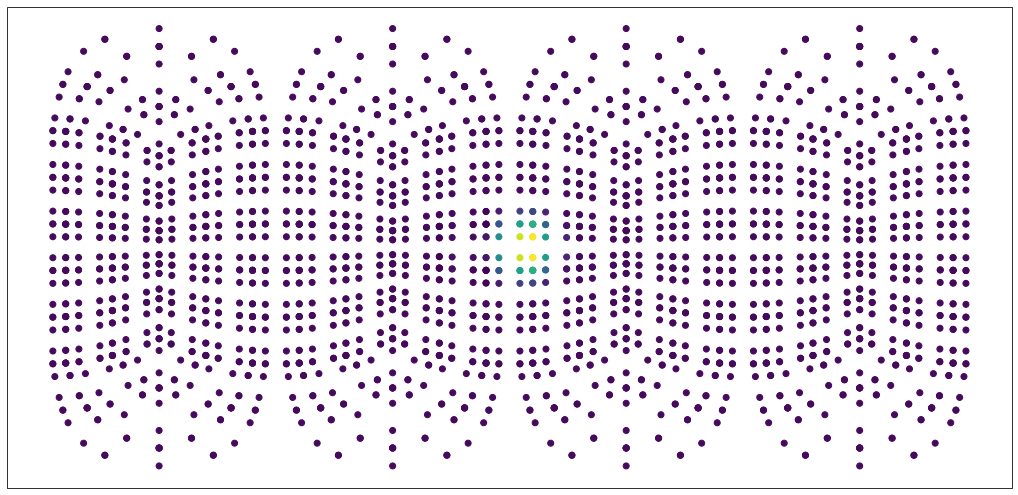

In [294]:
plt.figure(figsize=(18,10))
ax = plt.axes(projection=ccrs.PlateCarree())

sc = ax.scatter(lon_array.values.flatten(), lat_array.values.flatten(), 
                c = init.values.flatten(), cmap='viridis', transform=ccrs.PlateCarree())
# plt.colorbar(sc, ax=ax, label='Value')

In [292]:
init_mass = np.sum(np.sum(((det_J) * weights_2D_array) * init_cosine_bell(lat_array, lon_array, 1), axis = (1, 2)))
init_mass

<xarray.DataArray ()>
array(0.10342991)

In [293]:
sln_mass = np.sum(np.sum(((det_J) * weights_2D_array) * init, axis = (1, 2)))
sln_mass

<xarray.DataArray ()>
array(0.10342991)

In [118]:
np.round(init_mass, 14) == np.round(sln_mass, 14)

<xarray.DataArray ()>
array(False)

In [1201]:
# init.to_netcdf('2Dsph_ndiv_DGTransport_5000tps.nc')

### Unit Test:

In [1069]:
u_comp = np.cos(map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat'])
v_comp = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                      coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 'GLL_points' : (('x2', 'y2'), np.arange(len(GLL_points) ** 2).reshape(len(GLL_points), len(GLL_points)))},
                      dims = ['n_face', 'x2', 'y2'])
field_init = init_gaussian(lat_array, lon_array)

v_vector = xr.concat([u_comp, v_comp], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), y2 = np.arange(len(GLL_points)))

In [1087]:
# Alternative wind field:

lat_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lat']
lon_array = map_spherical(map_cartesian(grid_file, ref_coords, GLL_points)[0])['lon']

u_comp = (np.sin(lat_array) * np.cos(lon_array) * np.sin(np.pi / 2))
v_comp = -np.sin(lon_array) * np.sin(np.pi / 2)

v_vector = xr.concat([u_comp, v_comp], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), y2 = np.arange(len(GLL_points)))

In [40]:
lr_array = np.zeros((npts, npts))
tb_array = np.zeros((npts, npts))
lr_array[:, 0] = lr_array[:, -1] = 1
tb_array[0, :] = tb_array[-1, :] = 1

In [1028]:
bnd_array = np.zeros((npts, npts))
bnd_array[:, 0] = bnd_array[:, -1] = 1
bnd_array[0, :] = bnd_array[-1, :] = 1
bnd_array

array([[1., 1., 1., 1.],
       [1., 0., 0., 1.],
       [1., 0., 0., 1.],
       [1., 1., 1., 1.]])

In [1088]:
unit_RHS = (stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D) * W_ij) - weak_div(u_comp, v_comp, grid_file, ref_coords, GLL_points, npts, xr_D, W_ij)

In [41]:
line_int_weights = np.ones((npts, npts))
line_int_weights[0, :] = quad_weights(GLL_points)
line_int_weights[-1, :] = quad_weights(GLL_points)

In [42]:
b_array = np.ones((npts, npts))
b_array[-1, :] = -1
np.rot90(b_array, k = -1)

array([[-1.,  1.,  1.,  1.],
       [-1.,  1.,  1.,  1.],
       [-1.,  1.,  1.,  1.],
       [-1.,  1.,  1.,  1.]])

In [1090]:
flux_array = transport_analytic_flux(u_comp, v_comp, ones_array).drop_vars(['x2', 'y2'])
tb_array_flux_n = return_normal((flux_array * tb_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}),
                                    det_J, d_inv).isel(r_dim = 1) * line_int_weights * b_array
lr_array_flux_n = return_normal((flux_array * lr_array).assign_coords({'x2' : np.arange(npts), 'y2' : np.arange(npts)}),
                                    det_J, d_inv).isel(r_dim = 0) * np.rot90(line_int_weights, k = 1) * np.rot90(b_array, k = -1)

In [1095]:
# The unit test passes to 12 digits:
np.unique(np.round(unit_RHS, 13) == np.round(lr_array_flux_n + tb_array_flux_n, 13))

array([False,  True])

### DG Split-form w/ Strong-form divergence:

In [300]:
def DG_2D_stg_splfrm_dx(u_comp, v_comp, scalar_field, W_ij, det_J, d_inv, npts):
    v_vector = xr.concat([u_comp, v_comp], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), 
                                                                        y2 = np.arange(len(GLL_points)))
    # The three splitform terms w/o the 1/2's:
    stg_div_flux = stg_div(v_vector * scalar_field, grid_file, ref_coords, GLL_points, xr_D) 
    splfrm_term1 = (scalar_field * stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D))
    splfrm_term2 = (v_vector * stg_grad(scalar_field.assign_coords(x2 = np.arange(len(GLL_points)), 
                                                                   y2 = np.arange(len(GLL_points))), xr_D).rename({'c_dim' : 'r_dim'})).sum(dim = 'r_dim')
    # The first boundary term from int. by parts incorporates the DG centered fluxes: 
    # Note: There will be a sign change for bnd_term_1 pending if a centered (+) or upwind (-) flux is used:
    bnd_term_1 = DG_upwind_flux(u_comp, v_comp, scalar_field, det_J, d_inv, npts, nf_idx, x2_idx, y2_idx) / W_ij
    
    flux_array = transport_analytic_flux(u_comp, v_comp, scalar_field)
    # The second boundary term from int. by parts on weak div is just the outward flux normal:
    tb_array_flux_n = (return_normal((flux_array * tb_array), det_J, d_inv).isel(r_dim = 1) * line_int_weights * b_array) / W_ij
    lr_array_flux_n = (return_normal((flux_array * lr_array), det_J, d_inv).isel(r_dim = 0) * np.rot90(line_int_weights, k = 1) * np.rot90(b_array, k = -1)) / W_ij
    return((0.5 * stg_div_flux) + (0.5) * (splfrm_term1 + splfrm_term2) + bnd_term_1 - tb_array_flux_n - lr_array_flux_n)

### DG Split-form w/ Weak-form divergence - requires boundary term modification:

In [124]:
# The boundary terms should not be combined - the one from the PDE is discretized w/ a numerical flux
# The other boundary term is replaced with divergence theorem term

def DG_2D_wk_splfrm_dx(u_comp, v_comp, scalar_field, W_ij, det_J, d_inv, npts):
    v_vector = xr.concat([u_comp, v_comp], dim = 'r_dim').assign_coords(x2 = np.arange(len(GLL_points)), 
                                                                        y2 = np.arange(len(GLL_points)))
    # The three splitform terms w/o the 1/2's:
    weak_div_flux = weak_div(u_comp * scalar_field, v_comp * scalar_field, grid_file, 
                             ref_coords, GLL_points, npts, xr_D, W_ij) / W_ij 
    splfrm_term1 = (scalar_field * stg_div(v_vector, grid_file, ref_coords, GLL_points, xr_D))
    splfrm_term2 = (v_vector * stg_grad(scalar_field.assign_coords(x2 = np.arange(len(GLL_points)), 
                                                                   y2 = np.arange(len(GLL_points))), xr_D).rename({'c_dim' : 'r_dim'})).sum(dim = 'r_dim')
    # Boundary term with 1/2: 
    bnd_term = DG_upwind_flux(u_comp, v_comp, scalar_field, det_J, d_inv, npts, nf_idx, x2_idx, y2_idx) / W_ij
    return(0.5 * (weak_div_flux + splfrm_term1 + splfrm_term2 + bnd_term))

### Eigenvalue computation:

In [150]:
# Assume all RHS subroutines are linear functions in respects to the input scalar field (h):

In [227]:
zeros_array = xr.DataArray(np.zeros((grid_file.n_face, npts, npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 
                                     'x2' : (('x2'), np.arange(len(GLL_points))),
                                     'y2' : (('y2'), np.arange(len(GLL_points)))},
                           dims = ['n_face', 'x2', 'y2'])

ones_array = xr.DataArray(np.ones((grid_file.n_face, npts, npts)),
                           coords = {'n_face' : ('n_face', np.arange(grid_file.n_face)), 
                                     'x2' : (('x2'), np.arange(len(GLL_points))),
                                     'y2' : (('y2'), np.arange(len(GLL_points)))},
                           dims = ['n_face', 'x2', 'y2'])

In [ ]:
# Compute matrix columns for a given RHS subroutine:

In [301]:
def compute_DG_matrix_cols(RHS_func, u_comp, v_comp, grid_file, npts):
    output_array = np.zeros([grid_file.n_face * npts * npts, grid_file.n_face * npts * npts])
    input_array = np.zeros([grid_file.n_face * npts * npts]).reshape(-1)
    for i in np.arange(grid_file.n_face * npts * npts):
        input_array[i] = 1
        scalar_field = xr.DataArray(input_array.reshape(grid_file.n_face, npts, npts),
                                    coords = {'n_face' : np.arange(grid_file.n_face), 'x2' : np.arange(npts), 'y2' : np.arange(npts)},
                                    dims = ['n_face', 'x2', 'y2'])
        output_array[:, i] = RHS_func(u_comp, v_comp, scalar_field, W_ij, det_J, d_inv, npts).values.reshape(-1)
        input_array = np.zeros([grid_file.n_face * npts * npts]).reshape(-1)
    return(output_array)

In [302]:
DG_2D_splfrm_upwindflx_matrix = compute_matrix_cols(DG_2D_stg_splfrm_dx, u_comp, v_comp, grid_file, npts)

In [303]:
np.save('DG_2D_splfrm_upwindflx_matrix.npy', DG_2D_splfrm_upwindflx_matrix)